# TF-IDF + SVM MODEL - Consumer Reviews of Amazon Products

## 1. Import Data + Set Up

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from functions import load_splits, evaluate, LABELS, RANDOM_STATE

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = load_splits()
scores = []

## 2. Reference: baseline from the previous notebook

=== TF-IDF + LogReg (baseline) ===
              precision    recall  f1-score   support

    Negative       0.37      0.54      0.44       121
     Neutral       0.23      0.44      0.30       225
    Positive       0.97      0.92      0.95      4848

    accuracy                           0.89      5194
   macro avg       0.53      0.63      0.56      5194
weighted avg       0.93      0.89      0.91      5194



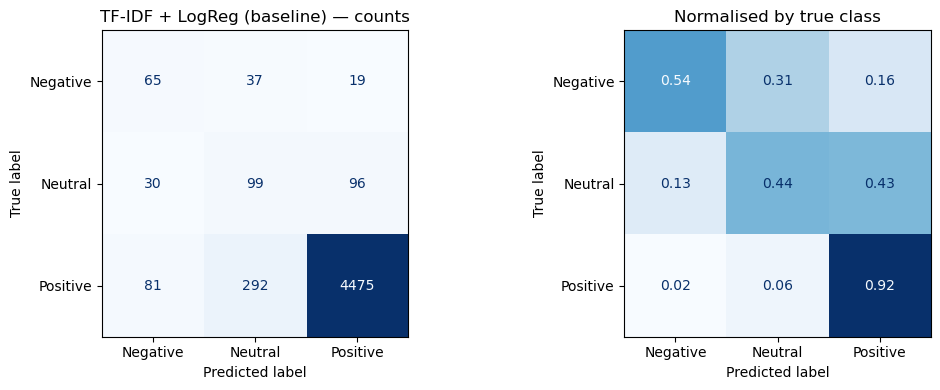

In [3]:
logreg = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9,
                              sublinear_tf=True, strip_accents="unicode",
                              stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
scores.append(evaluate(y_val, logreg.predict(X_val), "TF-IDF + LogReg (baseline)"))

## 3. TF-IDF + LinearSVC

=== TF-IDF + LinearSVC (balanced) ===
              precision    recall  f1-score   support

    Negative       0.58      0.39      0.47       121
     Neutral       0.37      0.25      0.30       225
    Positive       0.96      0.98      0.97      4848

    accuracy                           0.94      5194
   macro avg       0.64      0.54      0.58      5194
weighted avg       0.92      0.94      0.93      5194



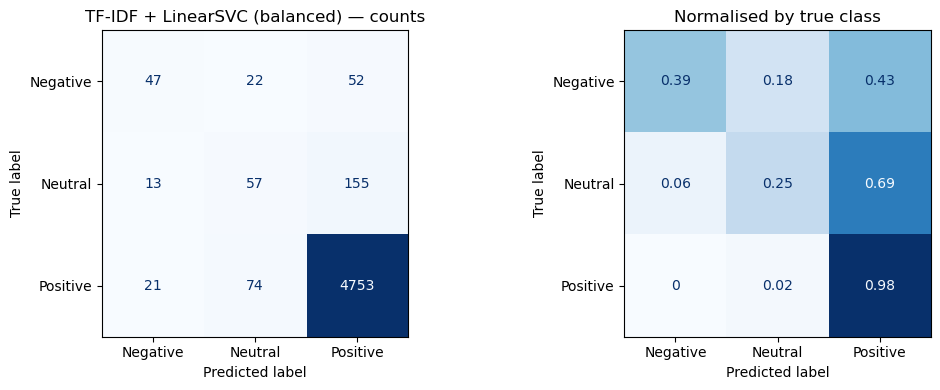

In [4]:
svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9,
                              sublinear_tf=True, strip_accents="unicode",
                              stop_words="english")),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
])
svm.fit(X_train, y_train)
scores.append(evaluate(y_val, svm.predict(X_val), "TF-IDF + LinearSVC (balanced)"))

## 4. Hyperparameter tuning

In [5]:
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 3, 5],
    "clf__C": [0.01, 0.05, 0.1, 0.3, 1.0],
}

grid = GridSearchCV(
    svm, param_grid,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'clf__C': 0.05, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}
Best CV macro-F1: 0.5890


=== TF-IDF + LinearSVC (tuned) ===
              precision    recall  f1-score   support

    Negative       0.58      0.44      0.50       121
     Neutral       0.40      0.25      0.31       225
    Positive       0.96      0.98      0.97      4848

    accuracy                           0.94      5194
   macro avg       0.65      0.56      0.59      5194
weighted avg       0.93      0.94      0.93      5194



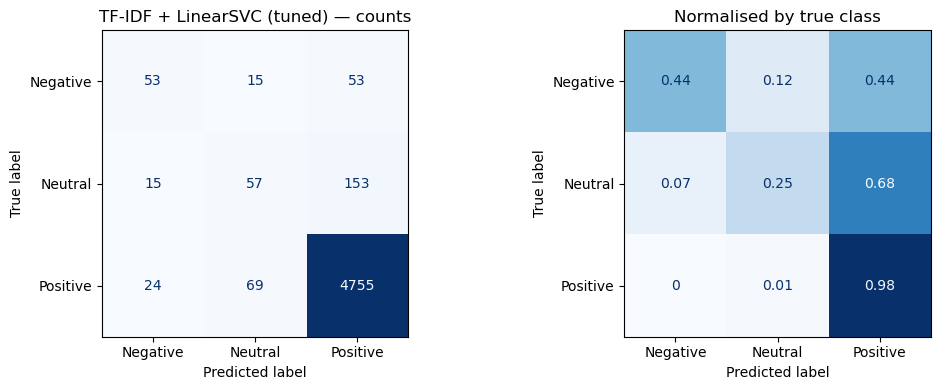

In [6]:
best_svm = grid.best_estimator_
scores.append(evaluate(y_val, best_svm.predict(X_val), "TF-IDF + LinearSVC (tuned)"))

## 5. Model comparison (validation set)

,accuracy,f1_macro,f1_negative,f1_neutral,f1_positive
model,,,,,
TF-IDF + LinearSVC (tuned),0.9367,0.5929,0.4977,0.3115,0.9695
TF-IDF + LinearSVC (balanced),0.9351,0.5787,0.4653,0.3016,0.9692
TF-IDF + LogReg (baseline),0.8931,0.5631,0.4377,0.3032,0.9483


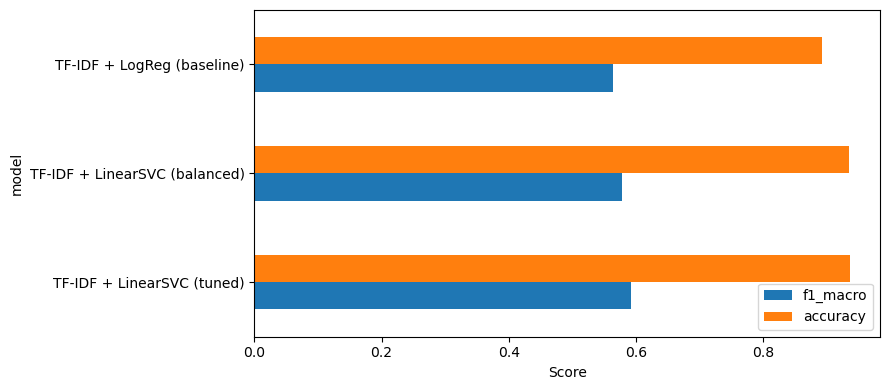

In [7]:
cmp = (pd.DataFrame(scores).set_index("model")
         .sort_values("f1_macro", ascending=False).round(4))
display(cmp[["accuracy", "f1_macro", "f1_negative", "f1_neutral", "f1_positive"]])

cmp[["f1_macro", "accuracy"]].plot(kind="barh", figsize=(9, 4))
plt.xlabel("Score"); plt.tight_layout(); plt.show()

## 6. Final evaluation on test set

=== TF-IDF + SVM — TEST ===
              precision    recall  f1-score   support

    Negative       0.45      0.49      0.47       122
     Neutral       0.37      0.24      0.29       225
    Positive       0.96      0.98      0.97      4847

    accuracy                           0.93      5194
   macro avg       0.59      0.57      0.58      5194
weighted avg       0.93      0.93      0.93      5194



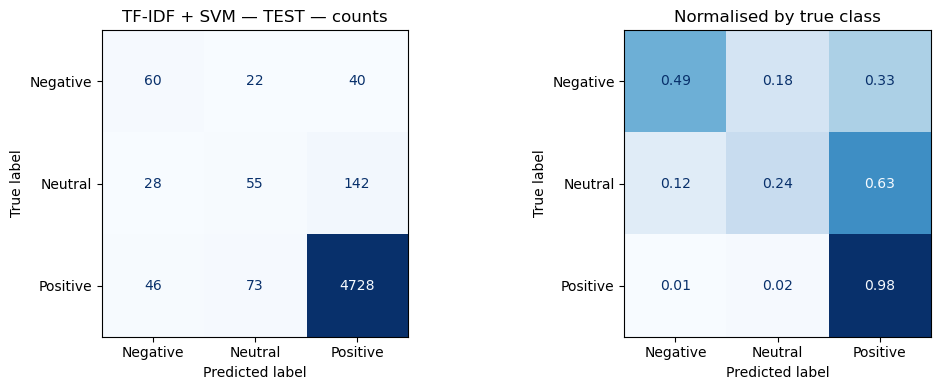

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,TF-IDF + SVM — TEST,0.9324,0.5706,0.5771,0.9281,0.4688,0.2933,0.9692


In [8]:
test_results = evaluate(y_test, best_svm.predict(X_test), "TF-IDF + SVM — TEST")
pd.DataFrame([test_results]).round(4)

## 7. Conclusions


### Findings

1. **The SVM improves on the baseline by +0.015 macro-F1**, driven by the Negative
   class. Neutral is unchanged.


4. **Strong regularisation** to prevent model from overfitting.

5. **The Neutral class remains unsolved** 63% of neutral reviews are
   predicted Positive. 3-star reviews mix positive and negative language.

### Limitation

33% of negative reviews are classified as Positive. The constraint could be the data, not model
choice: 812 negative reviews out of 34,626 is too few for classifier.

